In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches
from glob import glob
from skimage import io
import os
import matplotlib
from scipy.interpolate import CubicSpline
from lmfit.models import GaussianModel, LorentzianModel
matplotlib.rcParams.update({'errorbar.capsize': 4})


# Band-pass filters in wheel

In [23]:
ROOT = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/spectrometer_data/white_light_filters/white_light_only/'
ref_file = ROOT+'white_light_only_wheel.csv'
dark_file = ROOT+'filter2_blank.csv'
files = sorted(glob(ROOT+'filter*nm.csv'))
files.append(ref_file)

In [24]:
dfs = []
for f in files:
    name = os.path.split(f)[1][:-4]

    df = pd.read_csv(f, sep=';', skiprows=53, nrows=3648, names=['wv', name], index_col='wv')
    dfs.append(df)

filt_wheel = pd.concat([df for df in dfs] , axis=1)
filt_wheel

,filter03_438nm,filter04_472nm,filter05_549nm,filter06_575nm,filter07_586nm,filter08_605nm,filter09_631nm,filter10_661nm,filter11_676nm,filter12_692nm,white_light_only_wheel
wv,,,,,,,,,,,
193.175583,0.001076,0.000442,0.000593,0.000827,0.000564,0.000525,0.000452,0.000285,0.000299,0.000340,0.003880
193.379089,0.000364,-0.000180,-0.000188,0.000082,-0.000063,-0.000221,-0.000262,-0.000328,-0.000318,-0.000456,0.003031
193.582611,0.001592,0.000962,0.001228,0.001355,0.001193,0.001094,0.000967,0.000913,0.000865,0.000848,0.004434
193.786148,0.000201,-0.000308,-0.000236,0.000003,-0.000175,-0.000246,-0.000407,-0.000460,-0.000525,-0.000471,0.002691
193.989700,0.001034,0.000547,0.000600,0.000889,0.000646,0.000612,0.000426,0.000316,0.000233,0.000363,0.003751
...,...,...,...,...,...,...,...,...,...,...,...
1018.622620,-0.001293,-0.001238,-0.001275,-0.001216,-0.001180,-0.001124,-0.001279,-0.001181,-0.001233,-0.001220,-0.001161
1018.865662,-0.001696,-0.001717,-0.001699,-0.001706,-0.001713,-0.001516,-0.001580,-0.001774,-0.001590,-0.001772,-0.001666
1019.108704,-0.001180,-0.001245,-0.001180,-0.001280,-0.001173,-0.001189,-0.001235,-0.001241,-0.001306,-0.001208,-0.001062


[Text(0, 0.5, 'counts (arb. units)'), Text(0.5, 0, 'λ (nm)')]

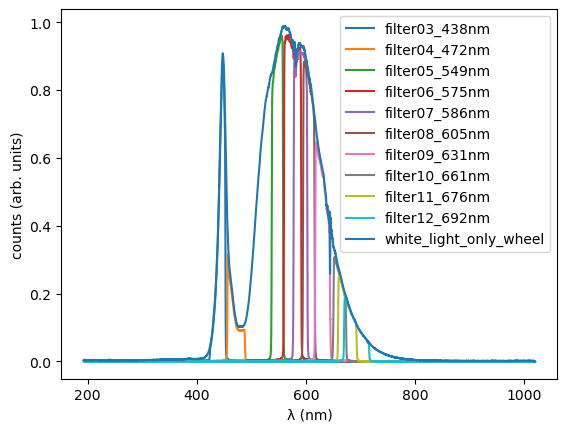

In [25]:
filt_wheel.plot()
plt.gca().set(xlabel='λ (nm)', ylabel='counts (arb. units)')

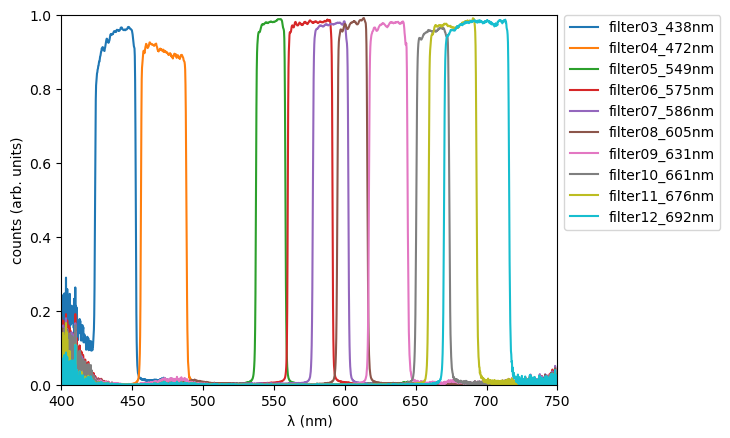

In [26]:
norm_wheel = pd.concat({c: filt_wheel[c] / filt_wheel.white_light_only_wheel for c in filt_wheel.columns if c != 'white_light_only_wheel'}, axis=1)
norm_wheel.plot()
plt.gca().set(xlim=(400, 750), ylim=(0,1), xlabel='λ (nm)', ylabel='counts (arb. units)')
plt.legend(bbox_to_anchor=(1., 0.4))


# Include dichroic mirror data

In [7]:
refdm_file = ROOT+'white_light_only_ref_dm.csv'
dm_file = ROOT+'Dichroic_mirror_550nm.csv'

dfref_dm = pd.read_csv(refdm_file, sep=';', skiprows=53, nrows=3648, names=['wv', 'ref_dm'], index_col='wv')

df_dm = pd.read_csv(dm_file, sep=';', skiprows=53, nrows=3648, names=['wv', 'counts'], index_col='wv')

norm_dm = pd.DataFrame({'Dichroic_mirror_550nm': df_dm.counts / dfref_dm.ref_dm})

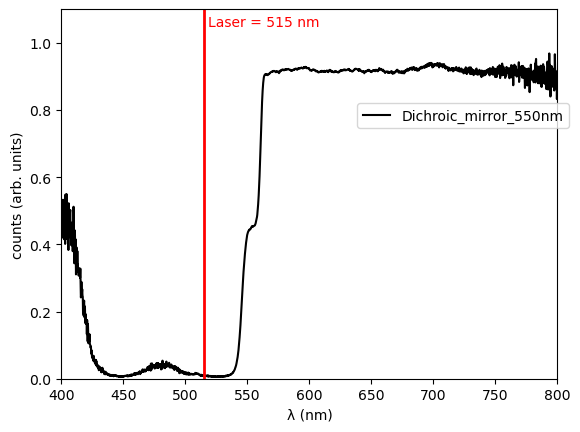

In [8]:
ax = norm_dm.plot(color='k')
ax.axvline(x = 515, color='red', lw=2)
ax.text(518, 1.05, s='Laser = 515 nm', color='red', ha='left')

plt.gca().set(xlim=(400, 800), ylim=(0,1.1), xlabel='λ (nm)', ylabel='counts (arb. units)')
ax.legend().remove()

plt.gcf().legend(bbox_to_anchor=(0.9, 0.7), )

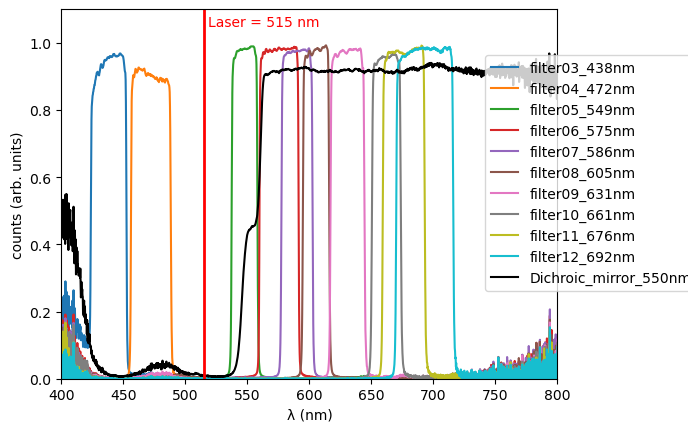

In [9]:
ax = norm_wheel.plot()
norm_dm.plot(ax=ax, color='k')
ax.axvline(x = 515, color='red', lw=2)
ax.text(518, 1.05, s='Laser = 515 nm', color='red', ha='left')

plt.gca().set(xlim=(400, 800), ylim=(0,1.1), xlabel='λ (nm)', ylabel='counts (arb. units)')
ax.legend().remove()

plt.gcf().legend(bbox_to_anchor=(1.1, 0.8), )

## Include Rhodamine B spectrum

In [10]:
file_rhb = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/spectra/emission/Rhodamine-B/Rhodamine_B_emission_extrapolate.txt'
df_rhb = pd.read_csv(file_rhb, names=['wv', 'counts'], skiprows=1, index_col='wv')
df_rhb.counts = df_rhb.counts / np.max(df_rhb.counts)
df_rhb.columns = ['Rhodamine B']

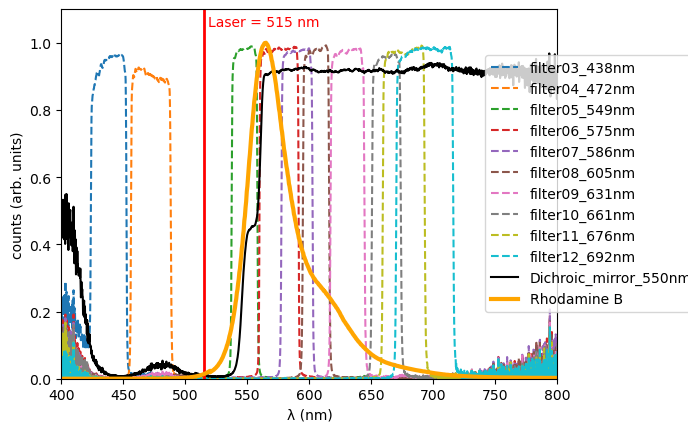

In [11]:
ax = norm_wheel.plot(ls='--')
norm_dm.plot(ax=ax, color='k')
ax.axvline(x = 515, color='red', lw=2)
ax.text(518, 1.05, s='Laser = 515 nm', color='red', ha='left')

df_rhb.plot(ax=ax, lw=3, color='orange')

plt.gca().set(xlim=(400, 800), ylim=(0,1.1), xlabel='λ (nm)', ylabel='counts (arb. units)')
ax.legend().remove()

plt.gcf().legend(bbox_to_anchor=(1.1, 0.8), )

# Include remaining filters: outside of the wheel

In [27]:
refext_file = ROOT+'white_light_only_ref.csv'
filt_ext_files = [ROOT+'filter500nm_right_direction.csv' , ROOT+'filter527nm_right_direction_0.csv', ROOT+'filter560nm_right_direction.csv']

dfref_ext = pd.read_csv(refext_file, sep=';', skiprows=53, nrows=3648, names=['wv', 'counts'])
dfref_ext = dfref_ext.set_index('wv')

dfs = []
for f in filt_ext_files:
    name = os.path.split(f)[1][:11]
    df = pd.read_csv(f, sep=';', skiprows=53, nrows=3648, names=['wv', name], index_col='wv')
    dfs.append(df)

df_ext = pd.concat([df for df in dfs], axis=1)

norm_ext = pd.concat({c: df_ext[c] / dfref_ext.counts for c in df_ext.columns }, axis=1)

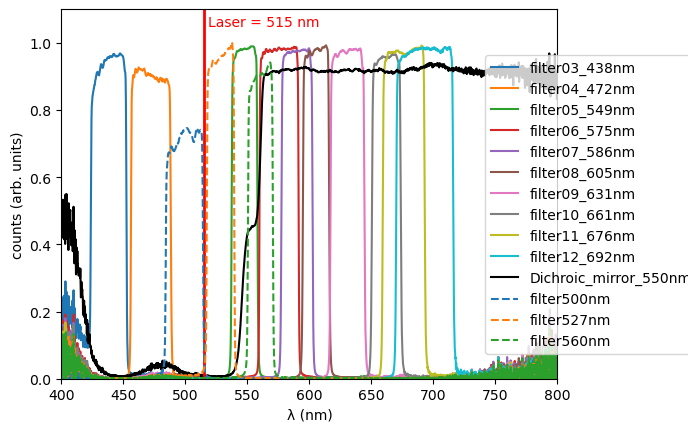

In [28]:
ax = norm_wheel.plot()
norm_dm.plot(ax=ax, color='k')
ax.axvline(x = 515, color='red', lw=2)
ax.text(518, 1.05, s='Laser = 515 nm', color='red', ha='left')

norm_ext.plot(ax=ax, ls='--')

plt.gca().set(xlim=(400, 800), ylim=(0,1.1), xlabel='λ (nm)', ylabel='counts (arb. units)')
ax.legend().remove()

plt.gcf().legend(bbox_to_anchor=(1.1, 0.8), )

# Calculate mean λ, range and transmission efficiency

In [14]:
cutoff = 0.7
def get_filter_stats(filt_series, cutoff):

    roi0 = filt_series.where(filt_series.index < 900).dropna()    # Define a ROI to remove noise in IR and UV
    roi = roi0.where(roi0.index > 400 ).dropna()
    filt_range0 = roi.where(roi.values > cutoff).dropna()    #  Define the filter range above a curtoff

    filt_range = (round(filt_range0.index[0], 1), round(filt_range0.index[-1], 1) )
    central_lambda = round( np.average(filt_range0.index, weights=filt_range0.values), 1)
    width = round( np.average(abs(filt_range - central_lambda)) , 1)
    mean_qe =  round( np.average(filt_range0, weights=filt_range0.values), 3)

    filt_stats = pd.DataFrame([{'central_lambda': central_lambda, 'range_width': width, 'mean_qe': mean_qe, 'range_low': filt_range[0], 'range_high': filt_range[1]}])
    return filt_stats

In [16]:
wheel_stats = pd.concat([get_filter_stats(norm_wheel[c], cutoff) for c in norm_wheel])
wheel_stats.index = norm_wheel.T.index

ext_stats = pd.concat([get_filter_stats(norm_ext[c], cutoff) for c in norm_ext])
ext_stats.index = norm_ext.T.index

filt_stats = pd.concat([wheel_stats, ext_stats])
filt_stats

,central_lambda,range_width,mean_qe,range_low,range_high
filter03_438nm,438.3,13.8,0.934,424.3,452.0
filter04_472nm,472.0,15.7,0.898,456.4,487.8
filter05_549nm,547.7,10.1,0.969,537.6,557.8
filter06_575nm,575.5,15.5,0.973,560.0,591.0
filter07_586nm,590.0,12.2,0.964,577.8,602.2
filter08_605nm,605.4,10.3,0.966,595.1,615.7
filter09_631nm,630.7,13.4,0.963,617.3,644.0
filter10_661nm,662.1,11.1,0.947,651.0,673.2
filter11_676nm,676.2,16.6,0.967,659.5,692.7
filter12_692nm,693.1,22.6,0.971,670.4,715.6


### Export data

In [ ]:
outpath = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/imag_analisis/filter_stats.csv'
filt_stats.to_csv(outpath)

# Comparing to specs

In [22]:
spec_file_dm = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/DMLP550.csv'
spec_data_dir = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/*.csv'
spec_files = sorted(glob(spec_data_dir))[:-2]
spec_files, len(spec_files)


(['/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/438.csv',
  '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/472.csv',
  '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/500.csv',
  '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/527.csv',
  '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/549.csv',
  '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/561.csv',
  '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/586.csv',
  '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/605.csv',
  '/Users/pabloherrero/Library/C

In [240]:
df_spec = []
for i, f in enumerate(spec_files):
    df = pd.read_csv(f, names=['wv', 'counts'], index_col='wv')
    df_spec.append(df)

spec_dm = pd.read_csv(spec_file_dm, sep=' ').iloc[:, :2] #, names = ['wv', 'counts', 'refl'], index_col='wv')
spec_dm.columns = ['wv', 'specs. Dichroic Mirror']
spec_dm = spec_dm.set_index('wv')
spec_dm.loc[:, 'specs. Dichroic Mirror'] /= 100

[(0.0, 1.1),
 Text(0, 0.5, 'counts (arb. units)'),
 (400.0, 800.0),
 Text(0.5, 0, 'λ (nm)')]

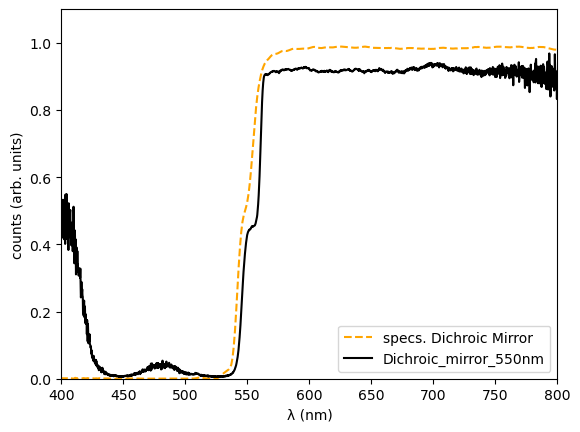

In [243]:
ax = spec_dm.plot(color = 'orange', ls='--')
norm_dm.plot(ax = ax, color='k', )

plt.gca().set(xlim=(400, 800), ylim=(0,1.1), xlabel='λ (nm)', ylabel='counts (arb. units)')


In [259]:
col = [a.get_color() for a in ax.get_lines()]
col

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf',
 '#1f77b4',
 '#ff7f0e',
 '#2ca02c']

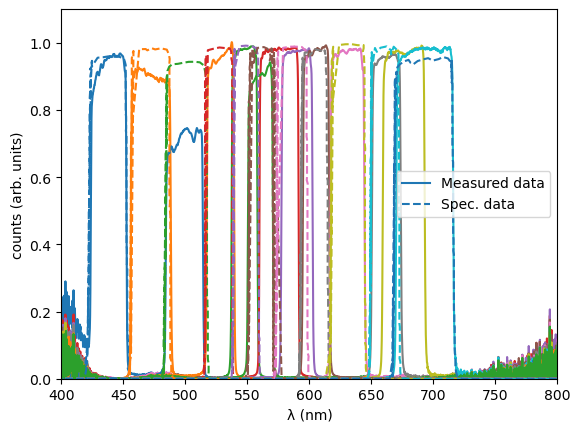

In [265]:
ax = norm_wheel.plot()
solid_line = ax.get_lines()[0]
norm_ext.plot(ax = ax)
col = ['#1f77b4', '#ff7f0e', '#2ca02c','#d62728', '#9467bd', '#8c564b', 
       '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#1f77b4','#ff7f0e', '#2ca02c']
for c, df in zip(col, df_spec):
    df.plot(ax = ax, ls = '--', color = c)

dash_line = ax.get_lines()[-1]
plt.gca().set(xlim=(400, 800), ylim=(0,1.1), xlabel='λ (nm)', ylabel='counts (arb. units)')
plt.legend().remove()
plt.legend([solid_line, dash_line] ,['Measured data', 'Spec. data'], )

# Rearrangement and Notch filter addition:

- Removed filter (07) 586 nm to use as “high-pass” filter

- Removed filter (04) 472 nm (only need the one at 438 nm for quartz autofluorescence)

- Shifted Filters at 549 nm and 575 nm one position up (so filter 05 → 06, and filter 06 → 07)

- Insert Filter at 527 +- 20 nm on position 05 (monitor laser reflection)

- Insert Filter at 500 +- 24 nm on position 04 (monitor laser reflection)

- Add notch filter OD6 514 nm right after dichroic mirror.

- Set Filter at 586 nm (old filter 07) on flip-mount (optional) as “long-pass” or double filter

- Updated filter_stats.csv

In [62]:
notch_path = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/QE calc/notch_fiilter_514nm.csv'
df_notch = pd.read_csv(notch_path, names=['wv', 'notch_filter_514nm'], index_col='wv')
df_notch

,notch_filter_514nm
wv,
300.5,9.500000e-07
301.0,9.500000e-07
301.5,9.500000e-07
302.0,9.949650e-07
302.5,9.500000e-07
...,...
1598.5,9.258880e-01
1599.0,9.248170e-01
1599.5,9.230430e-01


In [49]:
new_wheel = norm_wheel.copy()
new_columns = ['filter03_438nm', 'filter06_549nm', 'filter07_575nm', 'filter08_605nm',
       'filter09_631nm', 'filter10_661nm', 'filter11_676nm', 'filter12_692nm']
new_wheel.drop('filter07_586nm', axis=1, inplace=True)
new_wheel.drop('filter04_472nm', axis=1, inplace=True)
new_wheel.columns = new_columns
new_wheel['filter04_500nm'] = norm_ext['filter500nm']
new_wheel['filter05_527nm'] = norm_ext['filter527nm']
new_wheel = new_wheel.reindex(sorted(new_wheel.columns), axis=1)
new_wheel


,filter03_438nm,filter04_500nm,filter05_527nm,filter06_549nm,filter07_575nm,filter08_605nm,filter09_631nm,filter10_661nm,filter11_676nm,filter12_692nm
wv,,,,,,,,,,
193.175583,0.277253,0.132685,0.164835,0.152740,0.213076,0.135247,0.116467,0.073414,0.077056,0.087588
193.379089,0.119959,0.008252,-0.026399,-0.061887,0.027191,-0.073010,-0.086324,-0.108344,-0.104944,-0.150367
193.582611,0.359101,0.202175,0.292219,0.276958,0.305703,0.246646,0.218182,0.205985,0.195178,0.191315
193.786148,0.074713,-0.044443,0.001287,-0.087741,0.001298,-0.091337,-0.151242,-0.170951,-0.195110,-0.174854
193.989700,0.275799,0.188524,0.176553,0.159975,0.237006,0.163142,0.113665,0.084276,0.062012,0.096796
...,...,...,...,...,...,...,...,...,...,...
1018.622620,1.114363,0.807227,1.177653,1.098889,1.047376,0.968033,1.102399,1.017815,1.062594,1.051415
1018.865662,1.017947,0.799466,1.017741,1.019884,1.023796,0.909935,0.948378,1.064999,0.954147,1.063503
1019.108704,1.111082,0.787696,1.070820,1.110370,1.204961,1.119545,1.162659,1.168635,1.229452,1.137016


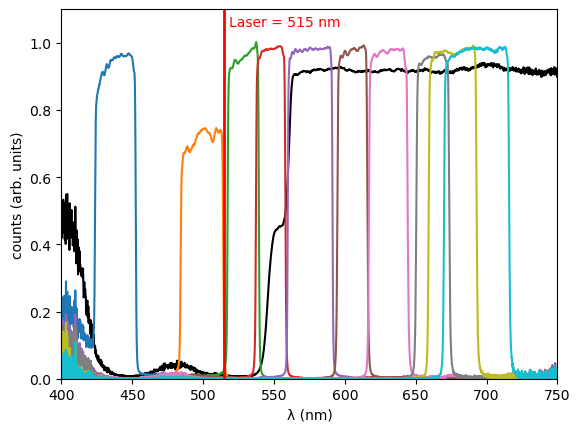

In [77]:
ax = norm_dm.plot(color='k')

new_wheel.plot(ax = ax)
# norm_wheel['filter07_586nm'].plot(ax=ax, color='b', ls='--', label='Double filter')
# df_notch.plot(ax=ax, color='m', ls='--', label='Notch filter 514 nm')

ax.axvline(x = 515, color='red', lw=2)
ax.text(518, 1.05, s='Laser = 515 nm', color='red', ha='left')


plt.gca().set(xlim=(400, 750), ylim=(0,1.1), xlabel='λ (nm)', ylabel='counts (arb. units)')
ax.legend().remove()
# plt.gcf().legend(bbox_to_anchor=(1.2, 0.8), )

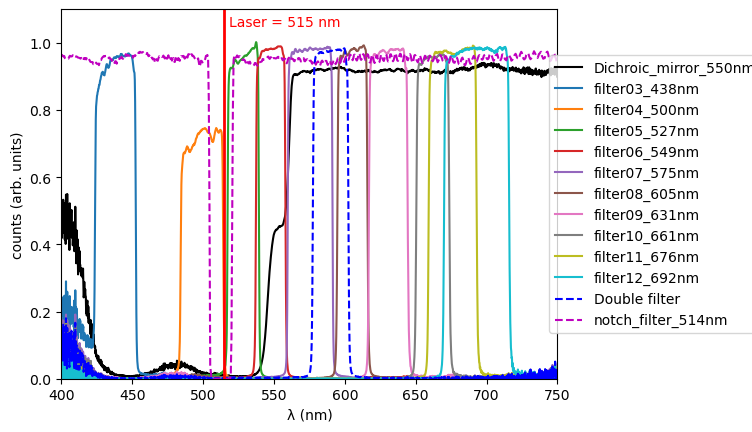

In [ ]:
ax = norm_dm.plot(color='k')

new_wheel.plot(ax = ax)
norm_wheel['filter07_586nm'].plot(ax=ax, color='b', ls='--', label='Double filter')
df_notch.plot(ax=ax, color='m', ls='--', label='Notch filter 514 nm')

ax.axvline(x = 515, color='red', lw=2)
ax.text(518, 1.05, s='Laser = 515 nm', color='red', ha='left')


plt.gca().set(xlim=(400, 750), ylim=(0,1.1), xlabel='λ (nm)', ylabel='counts (arb. units)')
ax.legend().remove()
plt.gcf().legend(bbox_to_anchor=(1.2, 0.8), )

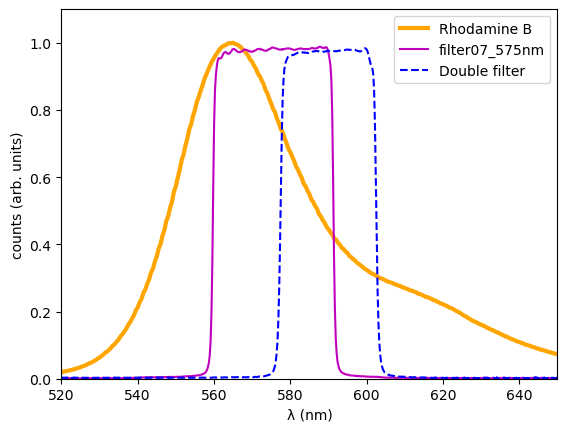

In [75]:
ax = df_rhb.plot(lw=3, color='orange', label='Rhodamine B')
new_wheel['filter07_575nm'].plot(ax = ax, color = 'm')
norm_wheel['filter07_586nm'].plot(ax=ax, color='b', ls='--', label='Double filter')
plt.gca().set(xlim=(520, 650), ylim=(0,1.1), xlabel='λ (nm)', ylabel='counts (arb. units)')
ax.legend()